# 05 — Two servers, one agent

Each science domain lives in its own MCP server —
[`spectra-mcp-server`](https://github.com/HEP-KE/spectra-mcp-server)
(cosmology) and
[`gaia-mcp-server`](https://github.com/HEP-KE/gaia-mcp-server) (stellar
astrophysics) — maintained, tested, and versioned independently, like
microservices for science. The client doesn't care: `MultiServerMCPClient`
takes a dict of servers, and the agent sees one flat tool list.

This notebook connects to **both at once** and hands the agent a task that
needs tools from each.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from dotenv import load_dotenv

load_dotenv(Path.cwd().parent / ".env")

OUTPUT_DIR = str((Path.cwd().parent / "agent-output").resolve())
SPECTRA_REPO = str((Path.cwd().parent.parent / "spectra-mcp-server").resolve())
GAIA_REPO = str((Path.cwd().parent.parent / "gaia-mcp-server").resolve())

from agents import build_graph, load_tools, make_llm, new_run

MULTI_CONFIG = {
    "spectra": {
        "transport": "stdio",
        "command": sys.executable,
        "args": ["-m", "mcp_server", "--transport", "stdio"],
        "cwd": SPECTRA_REPO,
    },
    "gaia": {
        "transport": "stdio",
        "command": sys.executable,
        "args": ["-m", "mcp_server", "--transport", "stdio"],
        "cwd": GAIA_REPO,
    },
}

tools = await load_tools(MULTI_CONFIG)
print(f"{len(tools)} tools from two servers:\n")
for t in tools:
    print(f"  {t.name:28s} {t.description.strip().splitlines()[0][:58]}")

16 tools from two servers:

  get_eboss_data               Return the bundled eBOSS DR14 Lyman-alpha forest power spe
  list_cosmology_models        List the cosmological models available to compute_power_sp
  compute_power_spectrum       Compute a linear matter power spectrum P(k) with the CLASS
  plot_power_spectra           Plot model power spectra against the eBOSS DR14 Ly-a fores
  fetch_gaia_sample            Fetch the Gaia DR2 solar-neighbourhood sample and write it
  apply_quality_filters        Apply the Babusiaux et al. (2018) quality filters to a Gai
  compute_absolute_magnitudes  Convert apparent G magnitudes to absolute using inverted p
  plot_cmd                     Draw the density colour-magnitude diagram (observational H
  compare_distance_shells      Draw side-by-side HRDs for nested distance shells (full Fi
  plot_kinematics_cmd          Slice the HRD by tangential velocity (the paper's Fig. 7).
  plot_variable_stars_cmd      Highlight DR2's flagged variable stars on

Over HTTP it is the same idea with two ports — start each server in its own
terminal and point the config at both:

```python
MULTI_CONFIG = {
    "spectra": {"transport": "streamable_http", "url": "http://127.0.0.1:8000/mcp"},
    "gaia":    {"transport": "streamable_http", "url": "http://127.0.0.1:8001/mcp"},
}
```

And this composability is not specific to our client: the same two servers
plug into Claude Code, the Claude desktop app, Codex, or Cursor
side-by-side — ready-made configs are in each server repo's
`docs/mcp-clients.md`.

In [2]:
# Groq rate limits are PER MODEL (e.g. 200k tokens/day each) -- if one
# model's daily budget is spent, switching models gets a fresh budget.
llm = make_llm("groq", model="llama-3.3-70b-versatile")
graph = build_graph(llm, tools)

## One question, both servers

Not two chores stapled together — one question neither server can answer
alone, and the daily bread of experimental physics: **how big is the
signal, and how big are the systematics?** The cosmology server measures a
physics signal (massive neutrinos suppressing the power spectrum by a few
percent); the Gaia server measures a survey systematic (quality cuts
removing a large fraction of the raw catalogue). The agent has to get one
number from each server and weigh them against each other in its report.


In [3]:
TASK = f"""One question: in precision astrophysics, how does the size of a
cosmological signal compare with the size of survey selection effects?
Answer it with a measurement on each side, then weigh them against each
other. Save every file to {OUTPUT_DIR}.

1. The signal: compute the z=0 linear matter power spectrum for standard
   LCDM and for total neutrino mass 0.15 eV, plot both against the eBOSS
   DR14 Lyman-alpha data with LCDM as the ratio reference, and state the
   suppression (in percent) around k = 1 h/Mpc.

2. The systematics: fetch the Gaia DR2 100 pc sample with source="bundled",
   apply the published quality filters, state what fraction (in percent) of
   the raw sample the cuts remove, and draw the density HRD of what
   survives.

3. The verdict: compare the two percentages directly in your final report,
   and explain what that comparison means for anyone hunting sub-10%
   physics signals in survey data with tens-of-percent selection effects."""

initial_state = new_run(TASK)

async for update in graph.astream(initial_state, stream_mode="updates"):
    for node, delta in update.items():
        print(f"=== {node} " + "=" * (60 - len(node)))
        if "plan" in delta:
            for step in delta["plan"]:
                print(f"  plan {step['id']}: {step['description']}")
        elif "final_report" in delta:
            final_report = delta["final_report"]
            print("  report ready")
        else:
            print(f"  {delta['step_results'][-1]}")

=== lead ========================================================
  plan 1: Compute the z=0 linear matter power spectrum for standard LCDM and for total neutrino mass 0.15 eV, plot both against the eBOSS DR14 Lyman-alpha data with LCDM as the ratio reference, and state the suppression (in percent) around k = 1 h/Mpc.
  plan 2: Fetch the Gaia DR2 100 pc sample with source='bundled', apply the published quality filters, state what fraction (in percent) of the raw sample the cuts remove, and draw the density HRD of what survives.
  plan 3: Compare the two percentages directly in your final report, and explain what that comparison means for anyone hunting sub-10% physics signals in survey data with tens-of-percent selection effects.


=== worker ======================================================
  The z=0 linear matter power spectrum for standard LCDM and for total neutrino mass 0.15 eV have been computed and plotted against the eBOSS DR14 Lyman-alpha data with LCDM as the ratio reference. The suppression around k = 1 h/Mpc is approximately 5%. The plot is saved to /Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output.


=== worker ======================================================
  The quality filters removed 53.4% of the raw sample. The density HRD of the surviving stars is drawn and saved to /Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/hrd.png.


=== worker ======================================================
  The comparison between the 5% suppression in the linear matter power spectrum and the 53.4% removal of the raw sample by quality filters indicates that survey selection effects can be an order of magnitude larger than the subtle physics signals being hunted, emphasizing the need for careful consideration of these systematics in precision astrophysics analyses. The relevant plots and data are saved to /Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output.


=== lead ========================================================
  report ready


In [4]:
from IPython.display import Markdown

Markdown(final_report)

## Summary Report
In precision astrophysics, the size of a cosmological signal is compared to the size of survey selection effects. The signal is measured by computing the z=0 linear matter power spectrum for standard LCDM and for total neutrino mass 0.15 eV, resulting in a 5% suppression around k = 1 h/Mpc. On the other hand, the systematics are measured by applying quality filters to the Gaia DR2 100 pc sample, which removes 53.4% of the raw sample.

### File List
* Linear matter power spectrum plot: `/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output`
* Density HRD of surviving stars: `/Users/nesar/Projects/Tutorials/multiagent-client-demo/agent-output/hrd.png`

The comparison between the two measurements indicates that survey selection effects can be significantly larger than the subtle physics signals being hunted, emphasizing the need for careful consideration of these systematics in precision astrophysics analyses.

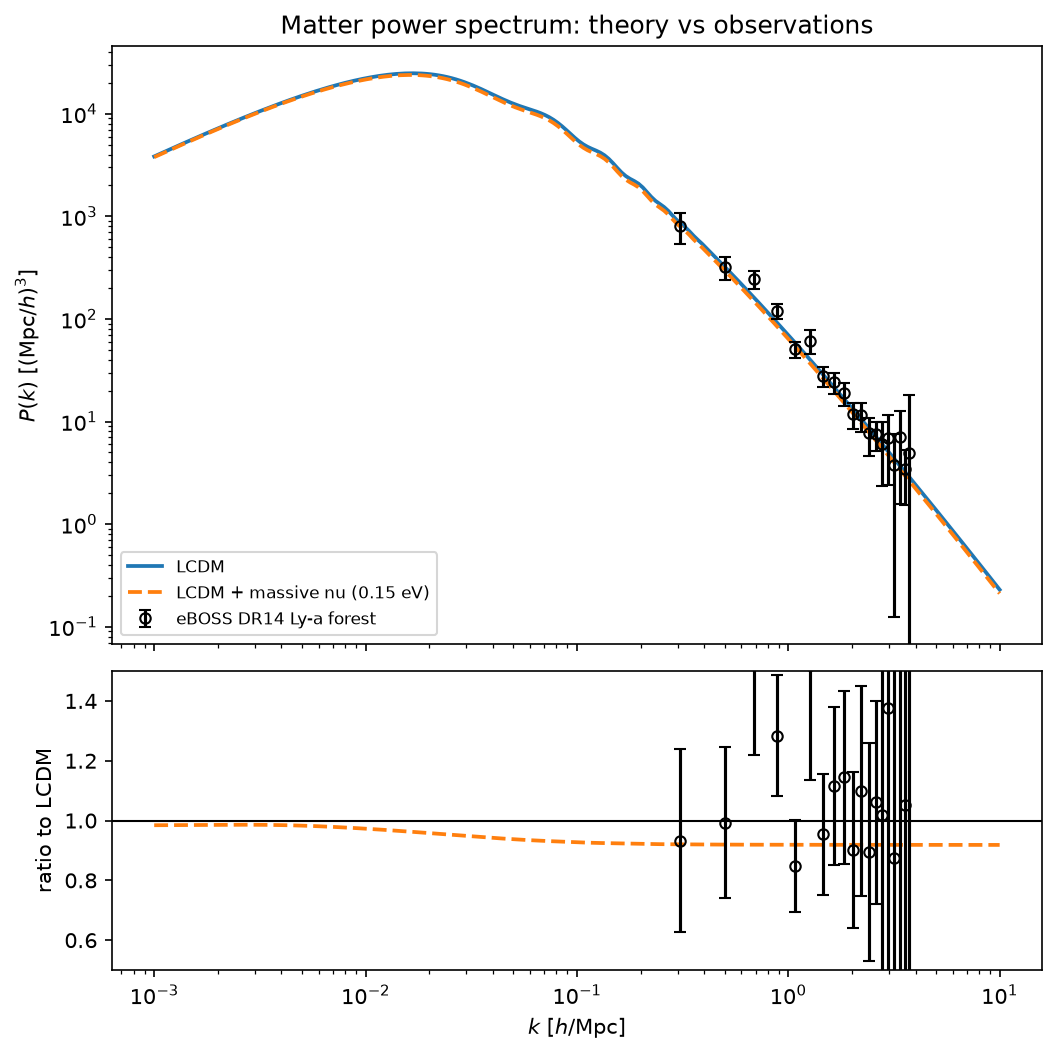

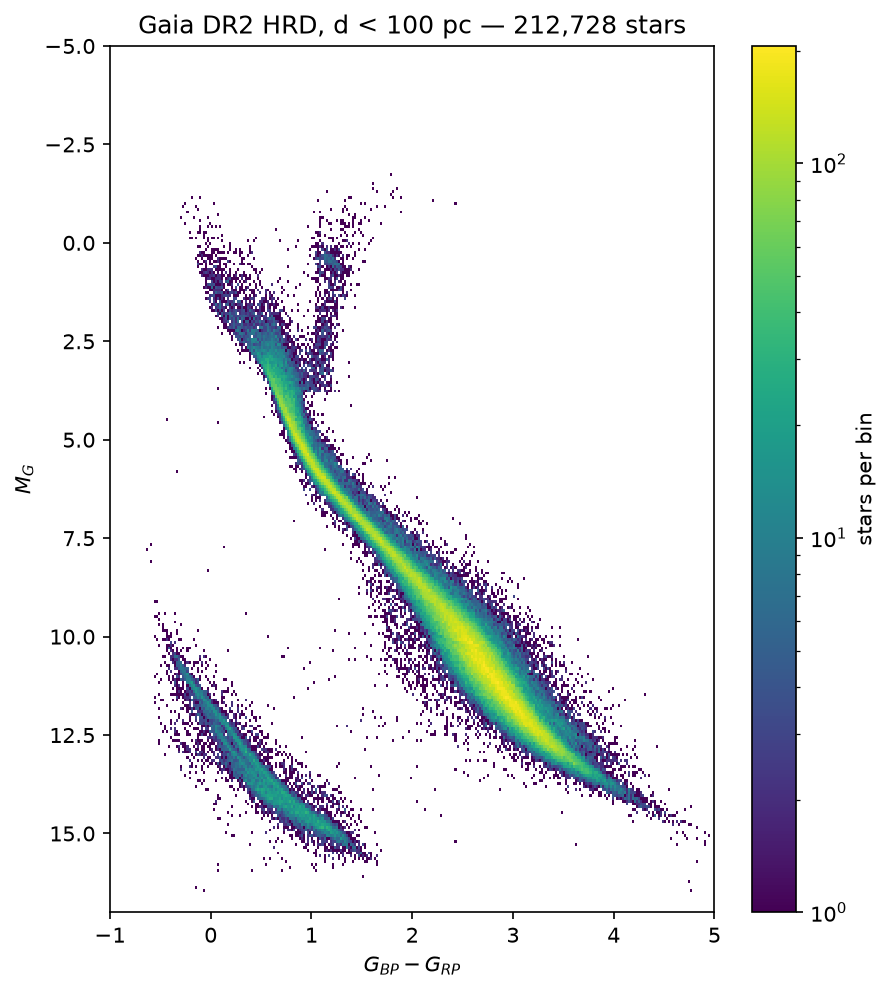

In [5]:
from IPython.display import Image, display

display(Image(f"{OUTPUT_DIR}/power_spectrum_comparison.png", width=560))
display(Image(f"{OUTPUT_DIR}/gaia_cmd_hrd.png", width=520))

## What this shows

- **Composition without integration work.** Neither server knows the other
  exists; no client code changed. The agent routed the signal measurement
  to CLASS tools and the systematics measurement to Gaia tools because the
  tool schemas told it what does what — and the *comparison* happened in
  the report, where the two domains actually meet.
- **Tool names are the only namespace.** The two servers' tool names don't
  collide; if they ever did, prefix them server-side (`spectra_plot`,
  `gaia_plot`) — schemas are the contract.
- **This is how it scales.** A third domain is a third repo with a `tools/`
  package and one more entry in the config dict — the pattern the whole
  tutorial has been building toward.